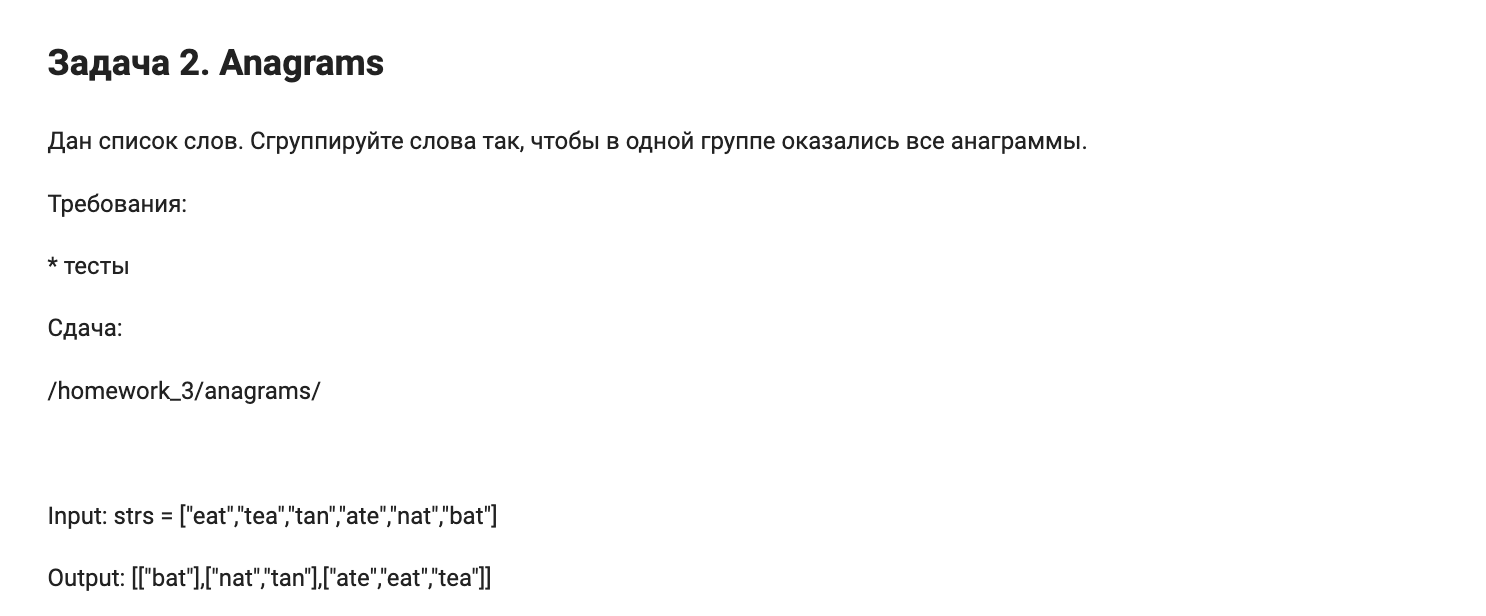

# Ход решения
* Заводим пустой словарь `pairs`. В нём будем хранить группы анаграмм.
* Самое сложно - это придумать, как построить единый ключ для них, и поэтому делаем следующее для каждого слова:
  * сначала используем`sorted(element)` , то есть сортируем буквы слова по алфавиту и складываем их в список
  * затем с помощью `''.join(...)` собираем отсортированные буквы обратно в строку.

Пример:

```text
"eat" -> "aet"
"tea" -> "aet"
"ate" -> "aet"
```

Теперь, у всех анаграмм получается одинаковый ключ, потому что они состоят из одинаковых букв в одинаковом количестве, и реализуем алгоритм:

Пробегаемся по массиву, каждый элемент превращаем в ключ и смотрим:

* Если такого ключа ещё нет в `pairs`, создаём новую группу: `pairs[key] = [element]`.

* Если ключ уже есть, добавляем слово в существующую группу: `pairs[key].append(element)`.

В конце в ключах словаря лежат отсортированные версии слов, а в значениях - нужные группы анаграмм. Поэтому возвращаем `list(pairs.values())`.


## Сложность алгоритма

Пусть:

- `n` — количество слов;
- `m` — максимальная длина слова, которая лежит в списке

Мы пробегаемся по всему массиву, тратя `n` времени, а также сортируем каждое слово.   
В худшем случае, отсортировав самое длинное слово потратим `O(m log m)` (так в питончике реализована сортировка), а сортируя каждое слово потратим `O(n · m log m)`

В случае с памятью под каждый ключ-строку мы резервируем дополнительное место в памяти.   
Самое длинное слово займет `m` места, а значит, что n слов в худшем случае, когда все слова одинаковой (максимальной) длины и все слова уникальные (т.е будет n ключей) займут `O(n * m)` места в памяти - оно уйдет под ключи. Тогда в итоге:

| Сущность | Сложность |
| --- | ---: |
| Время | `O(n · m log m)` |
| Доп. память | `O(n · m)` |

# Реализация

Реализуем функцию `group_anagrams`.

Порядок самих групп в ответе не важен: главное, чтобы все слова-анаграммы оказались в одной группе.

In [1]:
def group_anagrams(strs):
    pairs = {}

    for element in strs:
        key = ''.join(sorted(element))

        if key not in pairs:
            pairs[key] = [element]
        else:
            pairs[key].append(element)

    return list(pairs.values())

# Визуализация работы алгоритма

Рассмотрим пример из условия:

```text
strs = ["eat", "tea", "tan", "bat", "ate", "nat"]
```

| Шаг | Слово | Ключ после сортировки | Действие |
| ---: | --- | --- | --- |
| 1 | `eat` | `aet` | создаём `aet: [eat]` |
| 2 | `tea` | `aet` | добавляем `tea` в группу `aet` |
| 3 | `tan` | `ant` | создаём `ant: [tan]` |
| 4 | `bat` | `abt` | создаём `abt: [bat]` |
| 5 | `ate` | `aet` | добавляем `ate` в группу `aet` |
| 6 | `nat` | `ant` | добавляем `nat` в группу `ant` |

После прохода по всем словам получаем словарь:

```text
{
    'aet': ['eat', 'tea', 'ate'],
    'ant': ['tan', 'nat'],
    'abt': ['bat']
}
```

Нам нужны только значения словаря, поэтому результат:

```text
[['eat', 'tea', 'ate'], ['tan', 'nat'], ['bat']]
```

Порядок групп может отличаться от примера в условии, но группировка остаётся той же.


# Тесты

Тесты проверяют:

- пример из условия;
- список из одного слова;
- случай, когда анаграмм нет;
- случай, когда все слова являются анаграммами;
- повторяющиеся слова;
- пустые строки;
- пустой входной список.

В тестах группы нормализуются сортировкой, потому что порядок групп в ответе не важен.


In [2]:
def normalize(groups):
    return sorted(sorted(group) for group in groups)


assert normalize(group_anagrams(
    ["eat", "tea", "tan", "bat", "ate", "nat"]
)) == normalize([
    ["bat"],
    ["nat", "tan"],
    ["ate", "eat", "tea"],
])

assert normalize(group_anagrams(["word"])) == [["word"]]

assert normalize(group_anagrams(
    ["one", "two", "three"]
)) == normalize([
    ["one"],
    ["two"],
    ["three"],
])

assert normalize(group_anagrams(
    ["listen", "silent", "enlist"]
)) == [["enlist", "listen", "silent"]]

assert normalize(group_anagrams(
    ["abc", "bca", "abc"]
)) == [["abc", "abc", "bca"]]

assert normalize(group_anagrams(
    ["", "", "a"]
)) == normalize([
    ["", ""],
    ["a"],
])

assert group_anagrams([]) == []

print("Все тесты пройдены")

Все тесты пройдены
